In [2]:
# Cell 1: Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Cell 2: Cargar y limpiar los datos
file_path = '../data/raw/accidentes_transito.csv'
df = pd.read_csv(file_path)

In [4]:
# Realizar una limpieza básica
# Eliminamos columnas irrelevantes o con demasiados valores nulos
# Suponemos que 'Codi_districte', 'Nom_districte', etc. son relevantes y no los eliminamos
df = df.drop(columns=['Numero_expedient', 'Coordenades_UTM_X_ED50', 'Coordenades_UTM_Y_ED50'], errors='ignore')


In [5]:
# Llenar valores nulos con una técnica simple, como forward fill
df.fillna(method='ffill', inplace=True)

C:\Users\usuario\AppData\Local\Temp\ipykernel_4652\3011572357.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [6]:
# Codificación de variables categóricas (esto es un ejemplo, ajusta según las variables)
df = pd.get_dummies(df, drop_first=True)

In [13]:
# Cell 3: Definir características (X) y objetivo (y)
# Supongamos que 'Descripcio_causa_mediata' es la variable objetivo (esto depende del caso específico)
print(df.columns)
X = df.drop(columns=['Descripcio_causa_mediata_No respectar distàncies', 
                     "Descripcio_causa_mediata_Manca d'atenció a la conducció"])
y = df['Descripcio_causa_mediata_No respectar distàncies']  # Aquí escogemos una causa de ejemplo


Index(['Codi_districte', 'Codi_barri', 'Codi_carrer', 'NK_Any', 'Mes_any',
       'Dia_mes', 'Hora_dia', 'Coordenada_UTM_X_ED50', 'Coordenada_UTM_Y_ED50',
       'Longitud_WGS84',
       ...
       'Descripcio_causa_mediata_Envair calçada contrària',
       'Descripcio_causa_mediata_Fallada mecànica o avaria',
       'Descripcio_causa_mediata_Gir indegut o sense precaució',
       'Descripcio_causa_mediata_Manca d'atenció a la conducció',
       'Descripcio_causa_mediata_Manca precaució efectuar marxa enrera',
       'Descripcio_causa_mediata_Manca precaució incorporació circulació',
       'Descripcio_causa_mediata_No cedir la dreta',
       'Descripcio_causa_mediata_No determinada',
       'Descripcio_causa_mediata_No respectar distàncies',
       'Descripcio_causa_mediata_No respectat pas de vianants'],
      dtype='object', length=3096)


In [14]:
# Cell 4: Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [16]:
# Cell 5: Entrenamiento del modelo de Regresión Logística
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=200)

In [17]:
# Predicciones y evaluación
y_pred_logreg = log_reg.predict(X_test)

In [18]:
# Reporte de clasificación
print("Resultados del modelo de Regresión Logística:")
print(classification_report(y_test, y_pred_logreg))

Resultados del modelo de Regresión Logística:
              precision    recall  f1-score   support

       False       0.88      1.00      0.94      2361
        True       0.00      0.00      0.00       309

    accuracy                           0.88      2670
   macro avg       0.44      0.50      0.47      2670
weighted avg       0.78      0.88      0.83      2670



c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

In [19]:
# Cell 6: Entrenamiento del modelo Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Predicciones y evaluación
y_pred_rf = rf_clf.predict(X_test)

In [21]:
# Reporte de clasificación
print("Resultados del modelo Random Forest:")
print(classification_report(y_test, y_pred_rf))

Resultados del modelo Random Forest:
              precision    recall  f1-score   support

       False       0.89      0.98      0.93      2361
        True       0.31      0.05      0.09       309

    accuracy                           0.88      2670
   macro avg       0.60      0.52      0.51      2670
weighted avg       0.82      0.88      0.84      2670



In [22]:
# Cell 7: Matriz de confusión para ambos modelos
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

Text(0.5, 1.0, 'Matriz de Confusión - Regresión Logística')

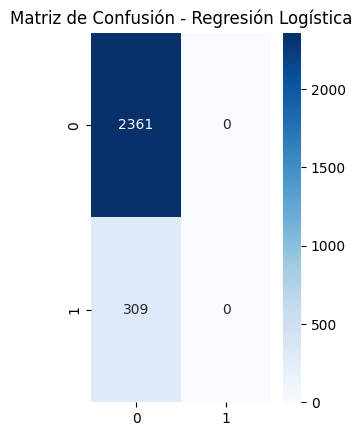

In [23]:
# Matriz de confusión para Regresión Logística
plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_logreg), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')

Text(0.5, 1.0, 'Matriz de Confusión - Random Forest')

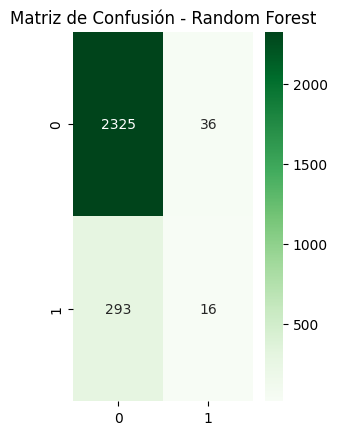

In [24]:
# Matriz de confusión para Random Forest
plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')

In [25]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>